Script: Predict variant effect on splicing with AlphaGenome
- Purpose:
   - Predict and visualize the splicing impact of the variant
     9_21968347_T_C (REF=T, ALT=C) using AlphaGenome.
   - Compare REF vs ALT predictions within a transcript-centered
     region of interest and summarize splice-junction changes.

 Variant:
   - 9_21968347_T_C

- Notes:
   - Ensure genome build consistency (e.g., GRCh38/hg38 vs hg19).
   - Confirm coordinate convention (1-based vs 0-based) before
     constructing prediction intervals.

 Author: Shelley
 Date:   2026-03-04
############################################################

In [1]:
# step.1 setup & import
from alphagenome import colab_utils
from alphagenome.data import gene_annotation, genome, track_data, transcript
from alphagenome.models import dna_client
from alphagenome.visualization import plot_components
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

dna_model = dna_client.create(api_key="YOUR_API_KEY_HERE")

# Load metadata objects for human.
output_metadata = dna_model.output_metadata(
    organism=dna_client.Organism.HOMO_SAPIENS
)

In [3]:
############################################################
# Step 2) Define the region for prediction input (CDKN2A, hg38)
#
# CDKN2A locus (reported 1-based, inclusive):
#   chr9:21,967,752-21,995,324  (minus strand)
#
# AlphaGenome Interval convention:
#   - 0-based start
#   - 0-based end (end-exclusive)
#   - width = end - start
#   - resize(width) returns a new Interval centered on the original center
############################################################

# -------------------------
# CDKN2A locus coordinates
# -------------------------
cdkn2a_chr = "chr9"
cdkn2a_start_1based = 21_967_752
cdkn2a_end_1based   = 21_995_324

# Convert to AlphaGenome Interval (0-based, end-exclusive)
cdkn2a_interval = genome.Interval(
    chromosome=cdkn2a_chr,
    start=cdkn2a_start_1based - 1,  # 1-based inclusive -> 0-based start
    end=cdkn2a_end_1based,          # 1-based inclusive end -> end-exclusive is the same value
    strand="-",
    name="CDKN2A",
)

# Resize to model-required 1 Mb input sequence length
# (resize centers on the interval's center; strand-aware by default)
interval_1mb = cdkn2a_interval.resize(dna_client.SEQUENCE_LENGTH_1MB)

# -------------------------
# Sanity checks / prints
# -------------------------
def _fmt_1based(iv: genome.Interval) -> str:
    # Convert back to 1-based inclusive for human-friendly display
    start_1based = iv.start + 1
    end_1based_inclusive = iv.end
    return f"{iv.chromosome}:{start_1based:,}-{end_1based_inclusive:,} ({iv.strand})"

print("Original locus (AlphaGenome Interval, 0-based):")
print("  ", cdkn2a_interval)
print("  ", "width =", cdkn2a_interval.width)
print("  ", "as 1-based inclusive:", _fmt_1based(cdkn2a_interval))

print("\nResized prediction interval (1 Mb):")
print("  ", interval_1mb)
print("  ", "width =", interval_1mb.width)
print("  ", "as 1-based inclusive:", _fmt_1based(interval_1mb))

Original locus (AlphaGenome Interval, 0-based):
   chr9:21967751-21995324:-
   width = 27573
   as 1-based inclusive: chr9:21,967,752-21,995,324 (-)

Resized prediction interval (1 Mb):
   chr9:21457249-22505825:-
   width = 1048576
   as 1-based inclusive: chr9:21,457,250-22,505,825 (-)


In [4]:
############################################################
# Step 3) Retrieve biosample / track metadata and available outputs
#
# OutputMetadata provides per-output-type metadata tables (DataFrames)
# such as: atac, cage, dnase, rna_seq, chip_histone, chip_tf,
# splice_sites, splice_site_usage, splice_junctions, contact_maps, procap.
#
# Key helpers:
#   - output_metadata.get(OutputType.<...>)         -> DataFrame | None
#   - output_metadata.concatenate()                 -> single DataFrame with column 'output_type'
############################################################

from alphagenome.models.dna_output import OutputType

# 3.1 Concatenate all metadata into a single DataFrame
meta_all = output_metadata.concatenate()
print("All metadata rows:", meta_all.shape[0])
print("All metadata columns:", meta_all.shape[1])
print("\nAvailable output types in this model:")
print(meta_all["output_type"].value_counts().sort_index())

# Peek (useful to learn column names like biosample_name / ontology CURIEs, etc.)
print("\nMetadata columns:")
print(list(meta_all.columns))

# 3.2 Focus on splicing-related outputs (what we need for variant splicing effect)
splicing_types = [
    OutputType.SPLICE_SITES,
    OutputType.SPLICE_SITE_USAGE,
    OutputType.SPLICE_JUNCTIONS,
]

for ot in splicing_types:
    df = output_metadata.get(ot)
    print("\n" + "=" * 80)
    print(f"{ot.name}:")
    if df is None:
        print("  (No metadata available for this output type in this model.)")
        continue

    print("  rows:", df.shape[0], "cols:", df.shape[1])
    print("  columns:", list(df.columns))

    # Show the first few tracks/biosamples (adjust head() as you like)
    display(df.head(10))

All metadata rows: 5563
All metadata columns: 15

Available output types in this model:
output_type
OutputType.ATAC                  167
OutputType.CAGE                  546
OutputType.DNASE                 305
OutputType.RNA_SEQ               667
OutputType.CHIP_HISTONE         1116
OutputType.CHIP_TF              1617
OutputType.SPLICE_SITES            4
OutputType.SPLICE_SITE_USAGE     734
OutputType.SPLICE_JUNCTIONS      367
OutputType.CONTACT_MAPS           28
OutputType.PROCAP                 12
Name: count, dtype: int64

Metadata columns:
['name', 'strand', 'Assay title', 'ontology_curie', 'biosample_name', 'biosample_type', 'biosample_life_stage', 'data_source', 'endedness', 'genetically_modified', 'nonzero_mean', 'output_type', 'gtex_tissue', 'histone_mark', 'transcription_factor']

SPLICE_SITES:
  rows: 4 cols: 2
  columns: ['name', 'strand']


,name,strand
0,donor,+
1,acceptor,+
2,donor,-
3,acceptor,-



SPLICE_SITE_USAGE:
  rows: 734 cols: 9
  columns: ['name', 'strand', 'Assay title', 'ontology_curie', 'biosample_name', 'biosample_type', 'biosample_life_stage', 'gtex_tissue', 'data_source']


,name,strand,Assay title,ontology_curie,biosample_name,biosample_type,biosample_life_stage,gtex_tissue,data_source
0,usage_CL:0000047 polyA plus RNA-seq,+,polyA plus RNA-seq,CL:0000047,neuronal stem cell,in_vitro_differentiated_cells,embryonic,,encode
1,usage_CL:0000062 total RNA-seq,+,total RNA-seq,CL:0000062,osteoblast,primary_cell,adult,,encode
2,usage_CL:0000084 polyA plus RNA-seq,+,polyA plus RNA-seq,CL:0000084,T-cell,primary_cell,adult,,encode
3,usage_CL:0000084 total RNA-seq,+,total RNA-seq,CL:0000084,T-cell,primary_cell,adult,,encode
4,usage_CL:0000100 total RNA-seq,+,total RNA-seq,CL:0000100,motor neuron,in_vitro_differentiated_cells,adult,,encode
5,usage_CL:0000115 total RNA-seq,+,total RNA-seq,CL:0000115,endothelial cell,in_vitro_differentiated_cells,adult,,encode
6,usage_CL:0000121 polyA plus RNA-seq,+,polyA plus RNA-seq,CL:0000121,Purkinje cell,primary_cell,child,,encode
7,usage_CL:0000127 total RNA-seq,+,total RNA-seq,CL:0000127,astrocyte,primary_cell,unknown,,encode
8,usage_CL:0000134 polyA plus RNA-seq,+,polyA plus RNA-seq,CL:0000134,mesenchymal stem cell,in_vitro_differentiated_cells,embryonic,,encode
9,usage_CL:0000137 total RNA-seq,+,total RNA-seq,CL:0000137,osteocyte,in_vitro_differentiated_cells,embryonic,,encode



SPLICE_JUNCTIONS:
  rows: 367 cols: 8
  columns: ['name', 'ontology_curie', 'biosample_name', 'biosample_type', 'biosample_life_stage', 'gtex_tissue', 'data_source', 'Assay title']


,name,ontology_curie,biosample_name,biosample_type,biosample_life_stage,gtex_tissue,data_source,Assay title
0,junction_CL:0000047 polyA plus RNA-seq,CL:0000047,neuronal stem cell,in_vitro_differentiated_cells,embryonic,,encode,polyA plus RNA-seq
1,junction_CL:0000062 total RNA-seq,CL:0000062,osteoblast,primary_cell,adult,,encode,total RNA-seq
2,junction_CL:0000084 polyA plus RNA-seq,CL:0000084,T-cell,primary_cell,adult,,encode,polyA plus RNA-seq
3,junction_CL:0000084 total RNA-seq,CL:0000084,T-cell,primary_cell,adult,,encode,total RNA-seq
4,junction_CL:0000100 total RNA-seq,CL:0000100,motor neuron,in_vitro_differentiated_cells,adult,,encode,total RNA-seq
5,junction_CL:0000115 total RNA-seq,CL:0000115,endothelial cell,in_vitro_differentiated_cells,adult,,encode,total RNA-seq
6,junction_CL:0000121 polyA plus RNA-seq,CL:0000121,Purkinje cell,primary_cell,child,,encode,polyA plus RNA-seq
7,junction_CL:0000127 total RNA-seq,CL:0000127,astrocyte,primary_cell,unknown,,encode,total RNA-seq
8,junction_CL:0000134 polyA plus RNA-seq,CL:0000134,mesenchymal stem cell,in_vitro_differentiated_cells,embryonic,,encode,polyA plus RNA-seq
9,junction_CL:0000137 total RNA-seq,CL:0000137,osteocyte,in_vitro_differentiated_cells,embryonic,,encode,total RNA-seq


In [5]:
# step.4 determine the biosample to be used for main prediction
# - melanocyte of skin
# - CL:1000458
ontology_terms = [
    'CL:1000458'
]

In [6]:
############################################################
# Step 5) Predict variant effect on splicing (REF vs ALT)
# Variant: 9_21968347_T_C (hg38, 1-based POS)
# Context: melanocyte (CL:1000458)
#
# We request splicing outputs:
#   - SPLICE_SITES (tissue-agnostic; ontology_terms ignored for this output)
#   - SPLICE_SITE_USAGE
#   - SPLICE_JUNCTIONS
# (Optionally include RNA_SEQ to visually align splicing with exon coverage.)
############################################################

# 5.1 Define the variant (AlphaGenome expects 1-based position)  :contentReference[oaicite:1]{index=1}
variant = genome.Variant(
    chromosome="chr9",
    position=21_968_347,        # 1-based
    reference_bases="T",
    alternate_bases="C",
)

# 5.2 Use your Step-2 prediction interval (1 Mb) as input
# interval_1mb should already exist from Step 2
# (Sanity: variant must be within interval)
assert interval_1mb.chromosome == variant.chromosome
assert interval_1mb.start <= (variant.position - 1) < interval_1mb.end

# 5.3 Make REF/ALT predictions (VariantOutput with .reference and .alternate) :contentReference[oaicite:2]{index=2}
requested_outputs = {
    dna_client.OutputType.RNA_SEQ,              # optional but helpful for interpretation
    dna_client.OutputType.SPLICE_SITES,
    dna_client.OutputType.SPLICE_SITE_USAGE,
    dna_client.OutputType.SPLICE_JUNCTIONS,
}

variant_output = dna_model.predict_variant(
    interval=interval_1mb,
    variant=variant,
    requested_outputs=requested_outputs,
    ontology_terms=ontology_terms,  # ['CL:1000458']
)

print("VariantOutput returned with REF and ALT predictions.")
print("REF outputs available:", [k for k in requested_outputs if hasattr(variant_output.reference, k.name.lower())])
print("ALT outputs available:", [k for k in requested_outputs if hasattr(variant_output.alternate, k.name.lower())])


VariantOutput returned with REF and ALT predictions.
REF outputs available: [SPLICE_SITES, SPLICE_JUNCTIONS, SPLICE_SITE_USAGE, RNA_SEQ]
ALT outputs available: [SPLICE_SITES, SPLICE_JUNCTIONS, SPLICE_SITE_USAGE, RNA_SEQ]


In [9]:
# 5.4 Extract splicing TrackData objects (REF vs ALT)
ref_splice_sites       = variant_output.reference.splice_sites
alt_splice_sites       = variant_output.alternate.splice_sites

ref_splice_site_usage  = variant_output.reference.splice_site_usage
alt_splice_site_usage  = variant_output.alternate.splice_site_usage

ref_splice_junctions   = variant_output.reference.splice_junctions
alt_splice_junctions   = variant_output.alternate.splice_junctions

# Optional: RNA-seq tracks for alignment
ref_rna = variant_output.reference.rna_seq
alt_rna = variant_output.alternate.rna_seq

# 5.5 For CDKN2A (minus strand), focus on negative-strand signals when applicable :contentReference[oaicite:3]{index=3}
ref_splice_sites_neg      = ref_splice_sites.filter_to_negative_strand()
alt_splice_sites_neg      = alt_splice_sites.filter_to_negative_strand()

ref_splice_usage_neg      = ref_splice_site_usage.filter_to_negative_strand()
alt_splice_usage_neg      = alt_splice_site_usage.filter_to_negative_strand()

ref_junctions_neg         = ref_splice_junctions.filter_to_negative_strand()
alt_junctions_neg         = alt_splice_junctions.filter_to_negative_strand()

ref_rna_neg               = ref_rna.filter_to_negative_strand()
alt_rna_neg               = alt_rna.filter_to_negative_strand()

print("Tracks prepared (negative strand).")
print("splice_sites:", ref_splice_sites_neg.values.shape)
print("splice_site_usage:", ref_splice_usage_neg.values.shape)
print("splice_junctions:", ref_junctions_neg.values.shape)
print("rna_seq:", ref_rna_neg.values.shape)

Tracks prepared (negative strand).
splice_sites: (1048576, 2)
splice_site_usage: (1048576, 1)
splice_junctions: (493, 1)
rna_seq: (1048576, 1)


In [24]:
ref_splice_sites_neg.values

array([[3.4645200e-07, 5.0291419e-07],
       [9.9185854e-08, 8.0466270e-07],
       [4.4517219e-07, 2.3096800e-07],
       ...,
       [8.7544322e-08, 1.5832484e-07],
       [6.0070306e-08, 1.2386590e-07],
       [3.4645200e-07, 1.9185245e-07]], shape=(1048576, 2), dtype=float32)

In [25]:
alt_splice_sites_neg.values

array([[3.2596290e-07, 4.7311187e-07],
       [9.9185854e-08, 8.0466270e-07],
       [4.4517219e-07, 2.3096800e-07],
       ...,
       [8.7544322e-08, 1.5832484e-07],
       [6.0070306e-08, 1.2386590e-07],
       [3.4645200e-07, 1.9185245e-07]], shape=(1048576, 2), dtype=float32)

In [28]:
import numpy as np

# ref_splice_sites_neg = minus_strand_tracks(ref_output.splice_sites)
# alt_splice_sites_neg = minus_strand_tracks(alt_output.splice_sites)

refV = np.asarray(ref_splice_sites_neg.values, dtype=np.float32)
altV = np.asarray(alt_splice_sites_neg.values, dtype=np.float32)

# Delta (ALT - REF)
deltaV = altV - refV
print("deltaV shape:", deltaV.shape)

# Max delta over ALL positions & both columns (donor/acceptor or channels)
max_delta = float(np.nanmax(deltaV))
arg_flat  = int(np.nanargmax(deltaV))
i, j = np.unravel_index(arg_flat, deltaV.shape)

print("\nGlobal max(ALT-REF):", max_delta)
print("  at row index i =", i, "col index j =", j)

# Map row index back to genomic coordinate (since shape[0] = 1,048,576 = 1Mb base-resolution)
iv = ref_splice_sites_neg.interval
genomic_pos0 = iv.start + i            # 0-based
genomic_pos1 = genomic_pos0 + 1        # 1-based

print("  interval:", f"{iv.chromosome}:{iv.start}-{iv.end} ({iv.strand})")
print("  genomic position (0-based):", f"{iv.chromosome}:{genomic_pos0}")
print("  genomic position (1-based):", f"{iv.chromosome}:{genomic_pos1}")
print("  value REF at max:", float(refV[i, j]))
print("  value ALT at max:", float(altV[i, j]))

# Also report max delta specifically at the variant coordinate (if you want)
pos0 = variant.position
offset = pos0 - iv.start
if 0 <= offset < deltaV.shape[0]:
    print("\nDelta at variant position (ALT-REF):", deltaV[offset, :], "(both columns)")
    print("  max over columns at variant:", float(np.nanmax(deltaV[offset, :])))
else:
    print("\nVariant is outside this interval; cannot extract delta at variant.")

deltaV shape: (1048576, 2)

Global max(ALT-REF): 0.87200927734375
  at row index i = 511098 col index j = 0
  interval: chr9:21457249-22505825 (.)
  genomic position (0-based): chr9:21968347
  genomic position (1-based): chr9:21968348
  value REF at max: 0.00689697265625
  value ALT at max: 0.87890625

Delta at variant position (ALT-REF): [8.7200928e-01 2.6464462e-04] (both columns)
  max over columns at variant: 0.87200927734375


In [10]:
############################################################
# Step 6) Retrieve transcript information for CDKN2A
#
# Goal:
#   - Load GENCODE v46 annotations
#   - Keep protein-coding transcripts with high support (TSL=1)
#   - Extract transcripts overlapping the CDKN2A locus
#   - Inspect transcript IDs and basic properties
#
# Notes:
#   - ROI for plotting will be determined later based on the
#     selected transcript structure.
############################################################

# ----------------------------------------------------------
# 6.1 Load gene annotations (GENCODE v46, hg38)
# ----------------------------------------------------------
gtf = pd.read_feather(
    "https://storage.googleapis.com/alphagenome/reference/gencode/"
    "hg38/gencode.v46.annotation.gtf.gz.feather"
)

print("Total rows in annotation:", gtf.shape)

# ----------------------------------------------------------
# 6.2 Filter annotations
#   - protein-coding genes
#   - transcript support level = 1
# ----------------------------------------------------------
gtf_transcript = gene_annotation.filter_transcript_support_level(
    gene_annotation.filter_protein_coding(gtf),
    ["1"]
)

print("Filtered annotation rows:", gtf_transcript.shape)

# ----------------------------------------------------------
# 6.3 Create transcript extractor
# ----------------------------------------------------------
transcript_extractor = transcript.TranscriptExtractor(gtf_transcript)

# ----------------------------------------------------------
# 6.4 Extract transcripts overlapping the CDKN2A locus
# ----------------------------------------------------------
txs_all = transcript_extractor.extract(cdkn2a_interval)

print("Number of transcripts overlapping CDKN2A locus:", len(txs_all))

E0304 16:37:28.000505 64376982 ssl_transport_security_utils.cc:114] Corruption detected.
E0304 16:37:28.000655 64376982 ssl_transport_security_utils.cc:71] error:1e000065:Cipher functions:OPENSSL_internal:BAD_DECRYPT
E0304 16:37:28.000712 64376982 ssl_transport_security_utils.cc:71] error:1000008b:SSL routines:OPENSSL_internal:DECRYPTION_FAILED_OR_BAD_RECORD_MAC
E0304 16:37:28.000765 64376982 secure_endpoint.cc:254] Decryption error: TSI_DATA_CORRUPTED


Total rows in annotation: (3467156, 27)
Filtered annotation rows: (808604, 27)
Number of transcripts overlapping CDKN2A locus: 3


In [11]:

# ----------------------------------------------------------
# 6.5 Inspect transcript basic information
# ----------------------------------------------------------
tx_summary = []

for tx in txs_all:
    tx_summary.append({
        "transcript_id": tx.transcript_id,
        "gene_id": tx.gene_id,
        "chromosome": tx.chromosome,
        "n_exons": len(tx.exons)
    })

tx_summary_df = pd.DataFrame(tx_summary)

print("\nTranscript summary:")
display(tx_summary_df)

# ----------------------------------------------------------
# 6.6 Print detailed structure for each transcript
# ----------------------------------------------------------
for tx in txs_all:
    print("--------------------------------------------------")
    print("Transcript:", tx.transcript_id)
    print("Gene ID:", tx.gene_id)
    print("Chromosome:", tx.chromosome)
    print("Number of exons:", len(tx.exons))


Transcript summary:


,transcript_id,gene_id,chromosome,n_exons
0,ENST00000304494.10,ENSG00000147889.18,chr9,3
1,ENST00000498124.1,ENSG00000147889.18,chr9,4
2,ENST00000579755.2,ENSG00000147889.18,chr9,3


--------------------------------------------------
Transcript: ENST00000304494.10
Gene ID: ENSG00000147889.18
Chromosome: chr9
Number of exons: 3
--------------------------------------------------
Transcript: ENST00000498124.1
Gene ID: ENSG00000147889.18
Chromosome: chr9
Number of exons: 4
--------------------------------------------------
Transcript: ENST00000579755.2
Gene ID: ENSG00000147889.18
Chromosome: chr9
Number of exons: 3


In [12]:
############################################################
# Step 6a) Get transcript span via transcript_interval
############################################################

# txs_all = transcript_extractor.extract(cdkn2a_interval)

tx_info = []
for tx in txs_all:
    tiv = tx.transcript_interval  # Interval with transcript span
    tx_info.append({
        "transcript_id": tx.transcript_id,
        "gene_id": tx.gene_id,
        "n_exons": len(tx.exons),
        "tx_start": tiv.start,
        "tx_end": tiv.end,
        "tx_width": tiv.width,
        "strand": tiv.strand,
        "chromosome": tiv.chromosome,
    })

tx_info_df = pd.DataFrame(tx_info).sort_values("tx_width", ascending=False)
display(tx_info_df)

# pick the longest transcript by span
tx_longest = txs_all[tx_info_df.index[0]]
tiv_longest = tx_longest.transcript_interval
print("Longest transcript:", tx_longest.transcript_id)
print("Transcript interval:", tiv_longest, "width =", tiv_longest.width)

,transcript_id,gene_id,n_exons,tx_start,tx_end,tx_width,strand,chromosome
2,ENST00000579755.2,ENSG00000147889.18,3,21967751,21994392,26641,-,chr9
0,ENST00000304494.10,ENSG00000147889.18,3,21967751,21974857,7106,-,chr9
1,ENST00000498124.1,ENSG00000147889.18,4,21968055,21974866,6811,-,chr9


Longest transcript: ENST00000579755.2
Transcript interval: chr9:21967751-21994392:- width = 26641


In [13]:
############################################################
# Step 7) Define plot region (plot_roi) from longest transcript
#
# Longest transcript selected:
#   ENST00000579755.2
# Transcript interval:
#   chr9:21967751-21994392 (strand -), width = 26641
############################################################

# tx_longest and tiv_longest should already exist from Step 6:
#   tx_longest   = Transcript object
#   tiv_longest  = tx_longest.transcript_interval  (genome.Interval)

print("Longest transcript:", tx_longest.transcript_id)
print("Transcript interval:", tiv_longest, "width =", tiv_longest.width)

# 7.1 Plot ROI = transcript interval (no padding)
plot_roi = tiv_longest

# 7.2 (Recommended) add padding for clearer splice junction visualization
# choose one: fixed padding OR resize
pad_bp = 0 # here we do not use any padding
plot_roi_pad = genome.Interval(
    chromosome=plot_roi.chromosome,
    start=max(0, plot_roi.start - pad_bp),
    end=plot_roi.end + pad_bp,
    strand=plot_roi.strand,
    name=f"{tx_longest.transcript_id}_pad{pad_bp//1000}kb",
)

# 7.3 Sanity checks: variant in plot ROI?
var_pos_1based = 21_968_347
var_pos_0based = var_pos_1based - 1

print("\nPlot ROI (no padding):", plot_roi, "width =", plot_roi.width)
print("Plot ROI (padded):    ", plot_roi_pad, "width =", plot_roi_pad.width)

in_roi = (plot_roi.chromosome == "chr9") and (plot_roi.start <= var_pos_0based < plot_roi.end)
in_roi_pad = (plot_roi_pad.chromosome == "chr9") and (plot_roi_pad.start <= var_pos_0based < plot_roi_pad.end)

print(f"\nVariant chr9:{var_pos_1based:,} in plot_roi?     {in_roi}")
print(f"Variant chr9:{var_pos_1based:,} in plot_roi_pad? {in_roi_pad}")

# Use padded by default for plotting
plot_roi = plot_roi_pad

Longest transcript: ENST00000579755.2
Transcript interval: chr9:21967751-21994392:- width = 26641

Plot ROI (no padding): chr9:21967751-21994392:- width = 26641
Plot ROI (padded):     chr9:21967751-21994392:- width = 26641

Variant chr9:21,968,347 in plot_roi?     True
Variant chr9:21,968,347 in plot_roi_pad? True


Transcripts in plot_roi: 3
Selected biosample_name for plotting: melanocyte of skin
REF junctions n = 493
ALT junctions n = 493


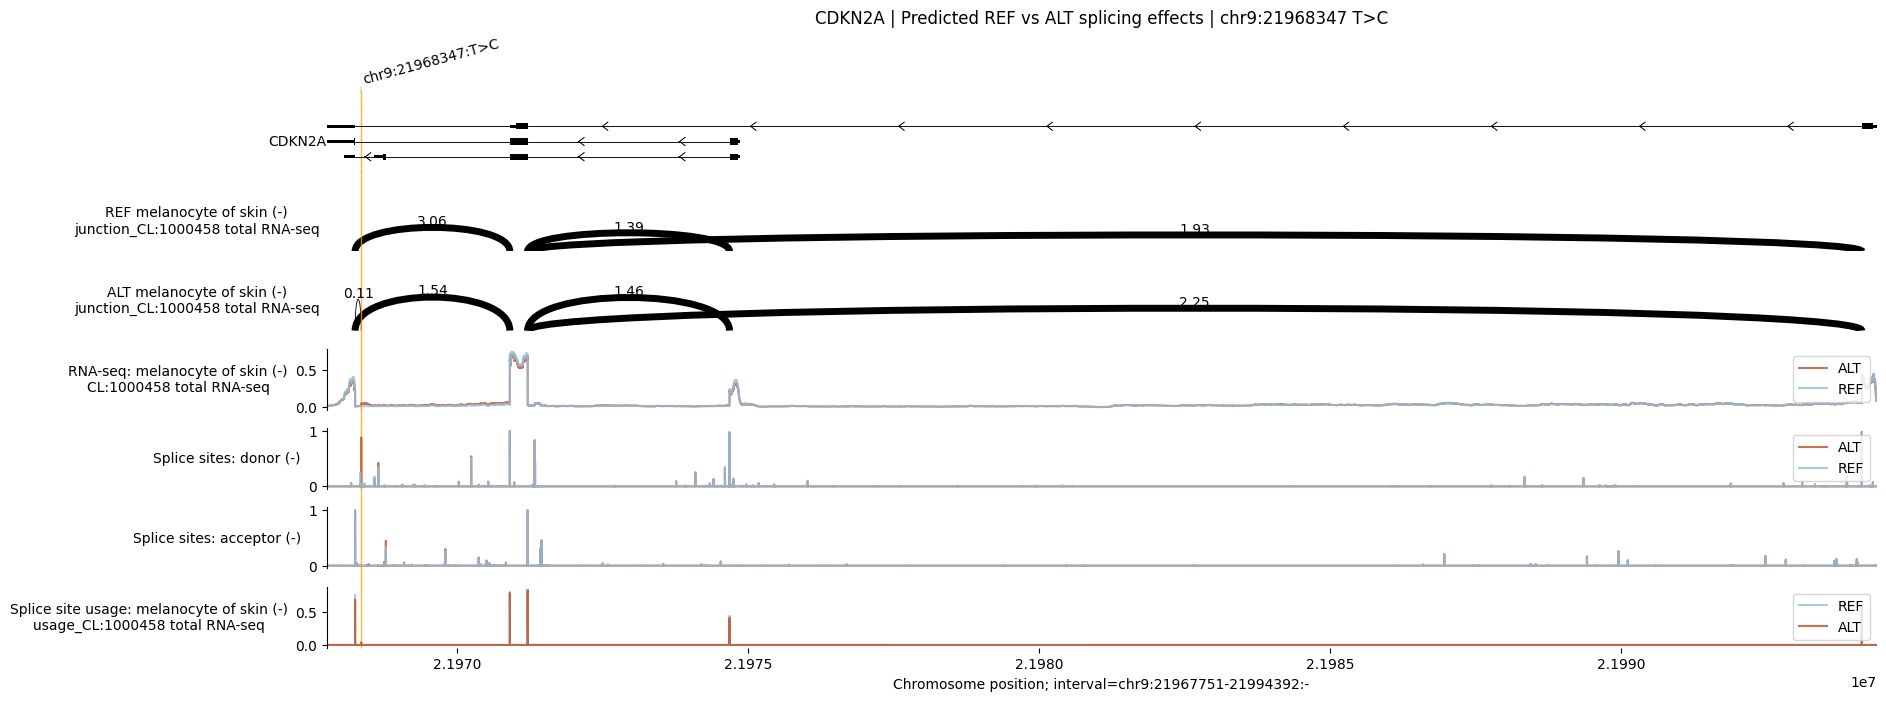

In [15]:
############################################################
# Whole-region plot (UPDATED) — ensure Sashimi junctions show up
############################################################

# Transcripts in plot ROI
transcripts_to_plot = transcript_extractor.extract(plot_roi)
print("Transcripts in plot_roi:", len(transcripts_to_plot))

ref_output = variant_output.reference
alt_output = variant_output.alternate

ref_alt_colors = {"REF": "#93bedd", "ALT": "#bd5028"}

# Pick biosample_name (for labeling / non-junction tracks)
def pick_first_biosample_name(tdata):
    md = getattr(tdata, "metadata", None)
    if md is None or len(md) == 0 or "biosample_name" not in md.columns:
        return None
    vals = md["biosample_name"].dropna().unique().tolist()
    return vals[0] if vals else None

bs = pick_first_biosample_name(ref_output.rna_seq)
print("Selected biosample_name for plotting:", bs)

# Strand filtering helpers
def minus_strand_tracks(tdata):
    # For base-resolution tracks (RNA-seq, splice sites, splice site usage)
    if hasattr(tdata, "filter_to_nonpositive_strand"):
        return tdata.filter_to_nonpositive_strand()
    if hasattr(tdata, "filter_to_negative_strand"):
        return tdata.filter_to_negative_strand()
    if hasattr(tdata, "filter_to_strand"):
        return tdata.filter_to_strand("-")
    return tdata

def minus_strand_junctions(junc):
    # For SPLICE_JUNCTIONS, prefer filter_to_strand('-') like the official example
    if hasattr(junc, "filter_to_strand"):
        return junc.filter_to_strand("-")
    return junc

# Optional biosample filter (ONLY if method exists)
def filter_by_biosample_name(tdata, biosample_name):
    if biosample_name is None:
        return tdata
    if hasattr(tdata, "filter_by_biosample_name"):
        return tdata.filter_by_biosample_name(biosample_name)
    if hasattr(tdata, "filter_by_biosample"):
        return tdata.filter_by_biosample(biosample_name)
    # Do NOT fall back to filter_by_tissue() here without checking labels
    return tdata

# Prepare junctions (IMPORTANT: do NOT call filter_by_tissue() blindly)
ref_junc = minus_strand_junctions(ref_output.splice_junctions)
alt_junc = minus_strand_junctions(alt_output.splice_junctions)

# Sanity checks: do we actually have junctions?
# JunctionData stores junctions in .junctions and values in .values
print("REF junctions n =", getattr(ref_junc, "junctions", np.array([])).shape[0])
print("ALT junctions n =", getattr(alt_junc, "junctions", np.array([])).shape[0])

# Prepare other tracks (minus strand + biosample filter when possible)
ref_rna = filter_by_biosample_name(minus_strand_tracks(ref_output.rna_seq), bs)
alt_rna = filter_by_biosample_name(minus_strand_tracks(alt_output.rna_seq), bs)

ref_ss  = minus_strand_tracks(ref_output.splice_sites)
alt_ss  = minus_strand_tracks(alt_output.splice_sites)

ref_su  = filter_by_biosample_name(minus_strand_tracks(ref_output.splice_site_usage), bs)
alt_su  = filter_by_biosample_name(minus_strand_tracks(alt_output.splice_site_usage), bs)

# Sashimi settings (keep junctions even if they cross interval edges)
sashimi_kwargs = dict(
    interval_contained=False,   # key: avoid dropping boundary-crossing junctions
    filter_threshold=0.1,       # raise (e.g. 0.01) to declutter
    annotate_counts=True,
    normalize_values=True,
)

plot = plot_components.plot(
    [
        plot_components.TranscriptAnnotation(transcripts_to_plot),

        # Sashimi (splice junctions): REF vs ALT
        plot_components.Sashimi(
            ref_junc,
            ylabel_template="REF {biosample_name} ({strand})\n{name}",
            **sashimi_kwargs,
        ),
        plot_components.Sashimi(
            alt_junc,
            ylabel_template="ALT {biosample_name} ({strand})\n{name}",
            **sashimi_kwargs,
        ),

        # Overlaid tracks
        plot_components.OverlaidTracks(
            tdata={"REF": ref_rna, "ALT": alt_rna},
            colors=ref_alt_colors,
            ylabel_template="RNA-seq: {biosample_name} ({strand})\n{name}",
        ),
        plot_components.OverlaidTracks(
            tdata={"REF": ref_ss, "ALT": alt_ss},
            colors=ref_alt_colors,
            ylabel_template="Splice sites: {name} ({strand})",
        ),
        plot_components.OverlaidTracks(
            tdata={"REF": ref_su, "ALT": alt_su},
            colors=ref_alt_colors,
            ylabel_template="Splice site usage: {biosample_name} ({strand})\n{name}",
        ),
    ],
    interval=plot_roi,
    annotations=[plot_components.VariantAnnotation([variant])],
    title=(
        f"CDKN2A | Predicted REF vs ALT splicing effects | "
        f"{variant.chromosome}:{variant.position} {variant.reference_bases}>{variant.alternate_bases}"
    ),
)

In [62]:
plot.set_size_inches(9, 3)

plot.savefig(
    "/Users/shelleyz/Projects/Melanoma-WGS/Updated.rvPGS/Target.Variants.ExWAS/CDKN2A_splicing_panel.pdf",
    bbox_inches="tight",
    pad_inches=0.02
)